# Лабораторна 2. Від сирих даних до нейромережі

У цій лабораторній роботі ви пройдете повний цикл роботи з табличним датасетом для задачі регресії — від завантаження до порівняння моделей:

- дослідницький аналіз даних (EDA): загальний огляд, гістограми, кореляції;
- обробка пропусків і викидів;
- інженерія ознак;
- baseline: множинна лінійна регресія;
- нейромережа — підбір архітектури, функцій активації, оптимізатора власними експериментами;
- чесне порівняння моделей на test за метриками регресії (MSE, RMSE, MAE, R²).

Демо-ноутбук з лекції 3-4 — основа, звертайтесь до нього як до довідника, коли щось незрозуміло.

## 0. Опрацюйте демо-ноутбук з лекції
Прогляньте пояснення ноутбуку і запустіть всі клітинки демо-ноутбуку (крім тих секцій, в яких вказано, що їх запускати не можна).
Після цього дайте тут відповідь на запитання:
1. Чому для заповнення пропусків було обрано метод kNN?
2. Чому при тренуванні лінійної регресії train і val порівнюються лише на основі MSE, а після тренування на основі багатьох функцій? Проекспериментуйте в межах тренування з вибором функції і поділіться результатами.
3. Які висновки після клітинки 2.6 в демо Ви можете зробити?
4. Поясни для чого потрібен baseline в лінійній регресії і як він вираховується? Що є baseline для нейронної мережі?
5. Продемонструй дію всіх функцій активації на графіку функцій, згенерувавши 1000 випадкових значень Х і порахувавши для них Y через ці функції.
6. Яким чином в нейронній мережі утворилася така кількість параметрів, яка вказана після виконання 3.3?
7. Чи оптимально вибрано кількість епох в 3.5?

### 0.1 Мої відповіді:
1. Вибір методу kNN: Метод kNN-імпутації застосовується через те, що характеристики нерухомості (наприклад, кількість кімнат і спалень) мають сильні внутрішні залежності. Замість того, щоб заповнювати пропуски «сліпим» середнім значенням, kNN шукає найбільш схожі об'єкти (сусідів) за іншими ознаками і використовує їхні дані, що дозволяє максимально точно відновити втрачену інформацію.

2.Функції втрат та експеримент: MSE використовується для тренування, оскільки її математична форма (парабола) забезпечує чіткий і стабільний градієнт, завдяки якому оптимізатор легко спускається до глобального мінімуму. Проте для фінального аналізу людиною вона незручна, тому ми дивимось на RMSE, MAE та R², які показують помилку в реальних одиницях (наприклад, у доларах).
Результат експерименту з L1Loss: Якщо змінити функцію втрат на torch.nn.L1Loss() (яка оптимізує модулі, а не квадрати відхилень), фінальна якість моделі зазвичай падає. L1Loss не має крутих «стінок» параболи і значно слабше штрафує алгоритм за великі помилки на початку тренування. Через це оптимізатору складніше швидко знайти оптимальні ваги.

3.Висновки щодо ваг: Попередня стандартизація привела всі ознаки до єдиного масштабу, що дає нам змогу напряму порівнювати їхні ваги. Аналіз показав, що інженерія ознак була дуже ефективною: створені нами фічі diag_coord та bedperroom виявилися одними з найважливіших і посіли друге та третє місця за силою впливу. Натомість такі ознаки, як Population чи AveOccup, отримали ваги, близькі до нуля, тобто лінійна модель їх практично ігнорує.

4.Бейзлайн (Baseline): Це мінімальна межа якості, яка визначає, чи є сенс у використанні моделі. Для лінійної регресії бейзлайном виступає прогноз простого середнього значення ціни (без урахування жодних ознак). Якщо регресія показує гірший результат за звичайне середнє, вона не має цінності. Для нейронної мережі бейзлайном слугує вже навчена лінійна регресія: якщо складна архітектура з прихованими шарами не здатна побити результат простої лінії, її використання є невиправданим ускладненням.

5.Демонстрація функції активації:

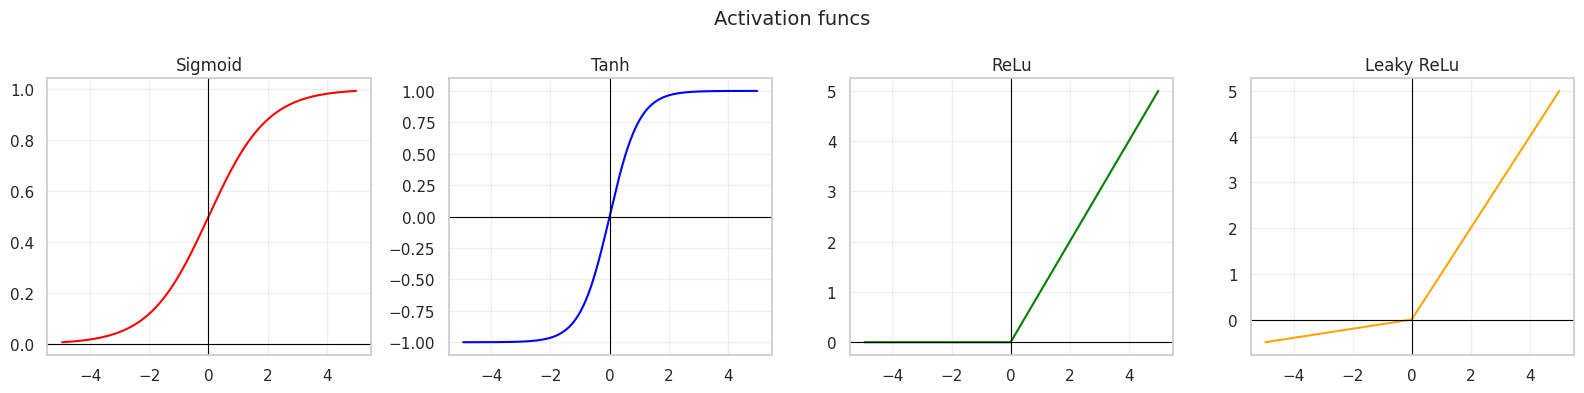

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.sort(np.random.uniform(-5, 5, 1000))

sigmoid = 1 / (1 + np.exp(-x))
tanh = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
relu = np.maximum(0, x)
leaky_relu = np.maximum(0.1 * x, x)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Activation funcs", fontsize=14)

functions = [
    (sigmoid, 'Sigmoid', axs[0], 'red'),
    (tanh, 'Tanh', axs[1], 'blue'),
    (relu, 'ReLu', axs[2], 'green'),
    (leaky_relu, 'Leaky ReLu', axs[3], 'orange')
]

for y, name, ax, c in functions:
    ax.plot(x, y, color=c)
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

6. Параметри є лише в лінійних шарах (функції активації їх не мають). Рахуються за формулою: (входи × нейрони) + нейрони (де останнє — це зсув, bias).

1-й шар: $7 \times 64 + 64 = 512$

2-й шар: $64 \times 32 + 32 = 2080$

Вихідний шар: $32 \times 1 + 1 = 33$

Разом: 2625 параметрів.

7. Ні, не оптимально. Значення val_loss усе ще продовжує падати. Оптимальний момент для зупинки — коли val_loss виходить на плато або починає зростати, що є ознакою початку перенавчання (overfitting). Експериментально оптимальна кількість епох становить близько 300.

---
## 1. Датасети

Ви отримаєте один з 10 датасетів нижче. Усі — задачі регресії на Hugging Face: табличні дані, здебільшого числові ознаки, від кількасот до кількадесяти тисяч рядків.

1. **[King County House Sales](https://huggingface.co/datasets/kraina/house_sales_in_king_county)** — 21 613 продажів будинків (Вашингтон, 2014–2015). Таргет: `price`. ⚠️ `load_dataset("kraina/house_sales_in_king_county")` не працює (застарілий loading-скрипт) — вантажте напряму: `load_dataset("parquet", data_files="https://huggingface.co/datasets/kraina/house_sales_in_king_county/resolve/main/data/house_sales_king_county.parquet")`.
2. **[Diamonds](https://huggingface.co/datasets/jdxcosta/diamonds)** — 53 940 діамантів. Таргет: `price`. Ознаки: вага (`carat`), огранка, колір, чистота, розміри.
3. **[Concrete Compressive Strength](https://huggingface.co/datasets/foundry-ml/dataset_concrete_compressive_strength)** — 1 030 замісів бетону. Таргет: міцність на стиск. Усі ознаки числові (склад суміші + вік).
4. **[Auto MPG](https://huggingface.co/datasets/scikit-learn/auto-mpg)** — 398 автомобілів. Таргет: `mpg` (витрата пального). Найменший і найпростіший датасет зі списку.
5. **[Wine Quality](https://huggingface.co/datasets/codesignal/wine-quality)** — 1 599 (червоне) + 4 898 (біле) вин. Таргет: `quality` (оцінка 3–9). Усі ознаки — хімічний склад, числові.
6. **[Laptop Price](https://huggingface.co/datasets/Ammok/laptop_price_prediction)** — 977 + 325 ноутбуків. Таргет: `Price`. Частина ознак текстові (`RAM`, `Storage`, `CPU`) — доведеться парсити в числа.
7. **[Bike Sharing Demand](https://huggingface.co/datasets/t22000t/bike-sharing-tabular)** — 17 379 годинних записів прокату велосипедів. Таргет: `cnt`. Часові й погодні ознаки.
8. **[Ames House Prices](https://huggingface.co/datasets/t22000t/house-prices-tabular)** — 1 460 будинків, 79 ознак. Таргет: `SalePrice`. Найбільше категоріальних ознак зі списку — гарна практика на encoding.
9. **[Medical Insurance Cost](https://huggingface.co/datasets/harishsohani/medical-insurance-cost-prediction)** — 1 338 застрахованих. Таргет: `charges`. Компактний, мало ознак — хороший старт, якщо часу мало. ⚠️ У репозиторії кілька CSV одразу (`Xtrain`/`Xtest`/`insurance.csv`) — вкажіть файл явно: `load_dataset("harishsohani/medical-insurance-cost-prediction", data_files="insurance.csv")`.
10. **[Abalone](https://huggingface.co/datasets/mstz/abalone)** — 4 177 молюсків. Таргет: `number_of_rings` (вік). Усі ознаки — фізичні виміри, окрім `sex`.

Решта (2–5, 7–8, 10) вантажаться напряму — `load_dataset("<repo_id>")` без додаткових аргументів, HF-токен не потрібен.

### 1.1. Який датасет мій?

Визначте самі власний датасет: беремо Ваше ПІБ, рахуємо SHA-256 хеш, залишок від ділення на 10 — це індекс у списку датасетів вище (0 → перший, 9 → останній).

**Формат ПІБ:** точно як у списку групи — `Прізвище Ім'я По-батькові`, по одному пробілу між словами, без зайвих пробілів на початку/в кінці. Якщо використаєте інший формат - **не зарахую лабу**!!!

In [42]:
import hashlib

DATASETS = [
    "King County House Sales",
    "Diamonds",
    "Concrete Compressive Strength",
    "Auto MPG",
    "Wine Quality",
    "Laptop Price",
    "Bike Sharing Demand",
    "Ames House Prices",
    "Medical Insurance Cost",
    "Abalone",
]

FULL_NAME = "Ренькас Альберт Олегович"

dataset_index = int(hashlib.sha256(FULL_NAME.encode("utf-8")).hexdigest(), 16) % len(DATASETS)
print(f"Ваш датасет (#{dataset_index + 1}):", DATASETS[dataset_index])

Ваш датасет (#10): Abalone


---
## 2. Що потрібно зробити

Нижче — загальний план роботи, без коду: код і пояснення до кожного кроку дивіться в **демо-ноутбуці лекції 3-4**, номери розділів позначені в дужках. Ваша задача — повторити той самий підхід на своєму датасеті, а не скопіювати код один в один: у вашого датасету інші колонки, інші типи пропусків (чи їх взагалі нема), інші викиди (чи їх нема) — рішення на кожному кроці обґрунтовуйте під свої дані, а не тому, що "так було в демо".

### 2.1. Підготовка даних

1. Завантажте свій датасет (демо 1.1) і перетворіть на `pandas.DataFrame` (1.2).
2. Зробіть спліт **train / val / test** одразу, до будь-якого аналізу (1.3) — і поясніть своїми словами, чому саме в такому порядку (нагадування: data leakage).
3. Загальний огляд (`head`/`info`/`describe`, 1.4).
4. Обробка пропусків (1.5) — **якщо вони є**. Немає пропусків — так і напишіть, це теж валідний результат, не треба їх штучно вигадувати.
5. EDA (1.6): хоча б гістограми і кореляційна матриця. Що впадає в очі у ваших даних — capping, скошені розподіли, мультиколінеарність?
6. Обробка викидів (1.7) — **за потреби**, з обґрунтуванням: звідки взявся викид і чому саме таке рішення (видалити / трансформувати / залишити).
7. Інженерія ознак (1.8) — **за потреби**: чи є сенс комбінувати/прибирати ознаки з високою кореляцією між собою.

### 2.2. Baseline: множинна лінійна регресія

Стандартизація ознак (2.1), тензори (2.2), тренування `nn.Linear` (2.3), крива навчання (2.4), метрики на test — MSE/RMSE/MAE/R² (2.5), інтерпретація ваг (2.6).

Це ваш **варіант #1**, точка відліку для всього, що далі.

### 2.3. Нейромережа: щонайменше 2 різні архітектури

За зразком розділу 3 демо: `nn.Sequential` з прихованими шарами, ReLU, оптимізатор Adam.

Спробуйте **мінімум 2 архітектури**, які відрізняються не косметично — напр. різна кількість шарів, різна ширина шарів, чи інша функція активації (3.2). Кожна — окремий варіант.

### 2.4. Підбір гіперпараметрів: щонайменше 3 зміни

Візьміть архітектуру, яка показала себе краще, і поекспериментуйте з гіперпараметрами: learning rate, оптимізатор (SGD/Adam), кількість епох, розмір batch (якщо вирішите його ввести) тощо. Змінюйте **по одному параметру за раз** — інакше не зрозумієте, що саме вплинуло на результат.

**Разом (2.2 + 2.3 + 2.4):** щонайменше 5 варіантів моделі (1 лінійна + 2 архітектури + 2 гіперпараметри), до **10 варіантів** — якщо є час і бажання поекспериментувати більше, це тільки заохочується.

### 2.5. Логування і порівняння

Кожен варіант (2.2-2.4) логуйте в TensorBoard в окрему підпапку `RUNS_DIR` (як у 2.3/3.5 демо) — з осмисленою назвою (`linear`, `nn_v1_2layers`, `nn_v2_deeper`, `nn_v2_lr_0.001`, ...), щоб потім усі криві можна було накласти одна на одну (3.8 демо) і візуально порівняти.

Наприкінці зведіть усі варіанти в одну таблицю (модель → MSE/RMSE/MAE/R² на test) і дайте коротку письмову відповідь:
- Яка модель перемогла і наскільки суттєво?
- Чи виправдала себе нейромережа порівняно з лінійною регресією на вашому датасеті?
- Що з ваших змін (архітектура чи гіперпараметри) дало найбільший ефект?

# 2.1 Підготовка даних


In [43]:
import sys
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

In [44]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("Seed зафіксовано:", SEED)

Seed зафіксовано: 42


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,number_of_rings
2830,F,0.525,0.430,0.135,0.8435,0.4325,0.1800,0.1815,9
925,I,0.430,0.325,0.100,0.3645,0.1575,0.0825,0.1050,7
3845,M,0.455,0.350,0.105,0.4160,0.1625,0.0970,0.1450,11
547,M,0.205,0.155,0.045,0.0425,0.0170,0.0055,0.0155,7
2259,F,0.590,0.465,0.160,1.1005,0.5060,0.2525,0.2950,13


<class 'pandas.core.frame.DataFrame'>
Index: 2923 entries, 2830 to 860
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              2923 non-null   object 
 1   length           2923 non-null   float64
 2   diameter         2923 non-null   float64
 3   height           2923 non-null   float64
 4   whole_weight     2923 non-null   float64
 5   shucked_weight   2923 non-null   float64
 6   viscera_weight   2923 non-null   float64
 7   shell_weight     2923 non-null   float64
 8   number_of_rings  2923 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 228.4+ KB


,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,number_of_rings
count,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000
mean,0.526143,0.409531,0.140128,0.836328,0.362982,0.182291,0.241286,9.983921
std,0.119723,0.098994,0.042487,0.492079,0.223530,0.109229,0.140562,3.238851
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.443750,0.187000,0.094500,0.130000,8.000000
50%,0.545000,0.425000,0.145000,0.808500,0.340000,0.173000,0.235000,10.000000
75%,0.615000,0.485000,0.165000,1.160250,0.508250,0.256000,0.330000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


Розмір навчальної вибірки (train): (2923, 9)
Розмір валідаційної вибірки (val): (627, 9)
Розмір тестової вибірки (test): (627, 9)
Empty DataFrame
Columns: [sex, length, diameter, height, whole_weight, shucked_weight, viscera_weight, shell_weight, number_of_rings]
Index: []


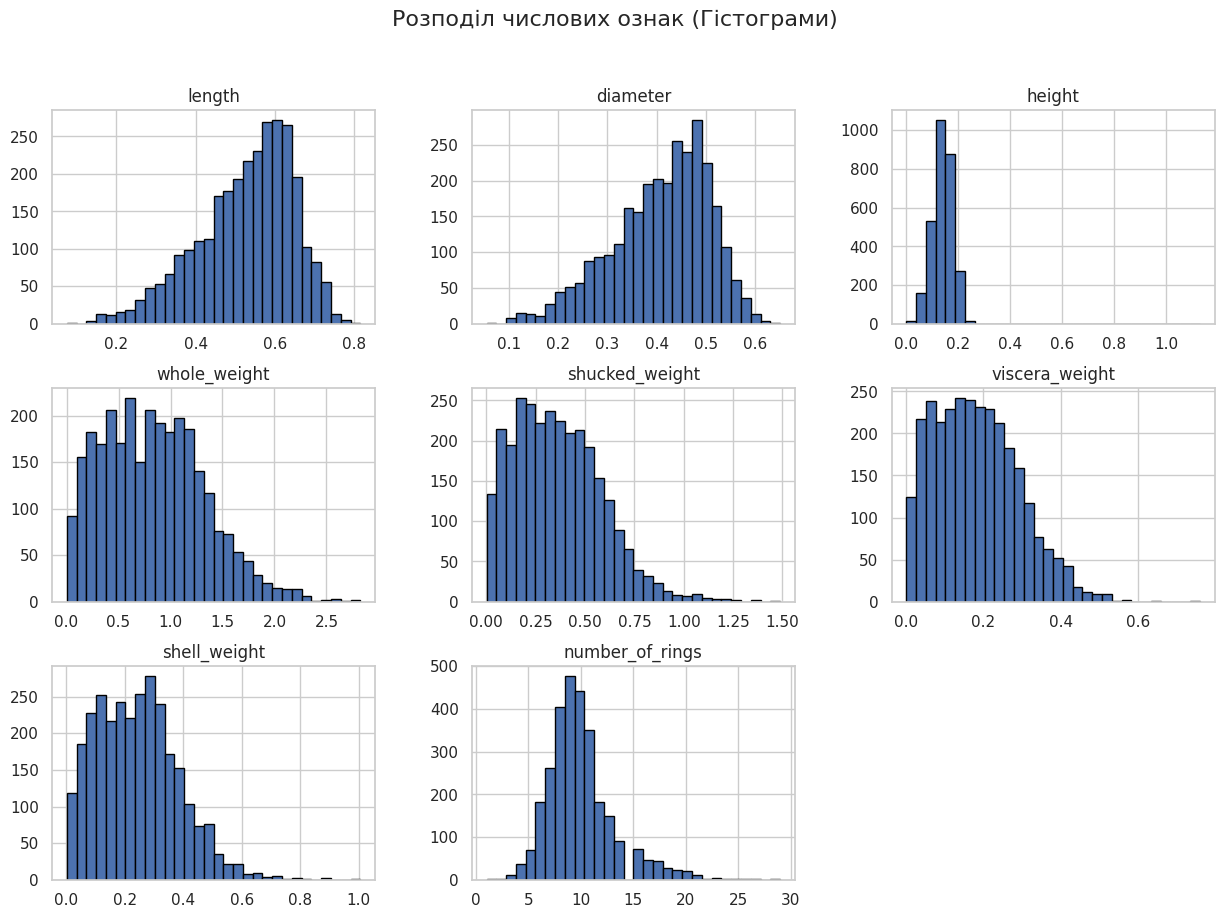

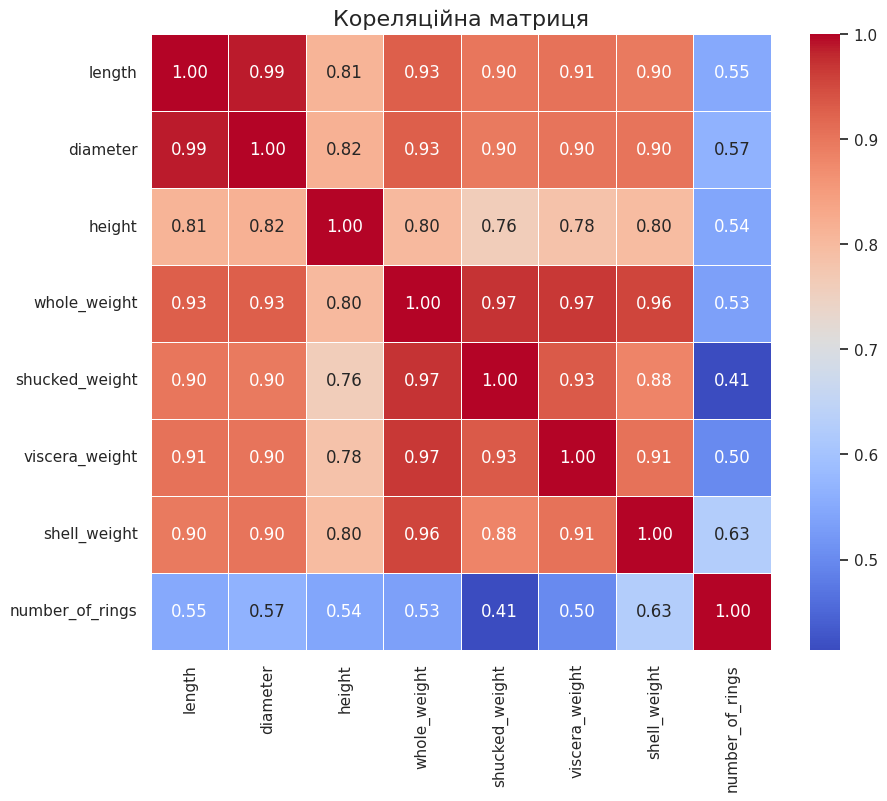

Аномалії по колонках 
length             0
diameter           0
height             2
whole_weight       0
shucked_weight     0
viscera_weight     0
shell_weight       0
number_of_rings    0
dtype: int64
     sex  diameter  height  whole_weight  number_of_rings  shape_index  \
2830   F     0.430   0.135        0.8435                9     0.819048   
925    I     0.325   0.100        0.3645                7     0.755814   
3845   M     0.350   0.105        0.4160               11     0.769231   
547    M     0.155   0.045        0.0425                7     0.756098   
2259   F     0.465   0.160        1.1005               13     0.788136   

      shucked_ratio  viscera_ratio  shell_ratio  
2830       0.512745       0.213397     0.215175  
925        0.432099       0.226337     0.288066  
3845       0.390625       0.233173     0.348558  
547        0.400000       0.129412     0.364706  
2259       0.459791       0.229441     0.268060  


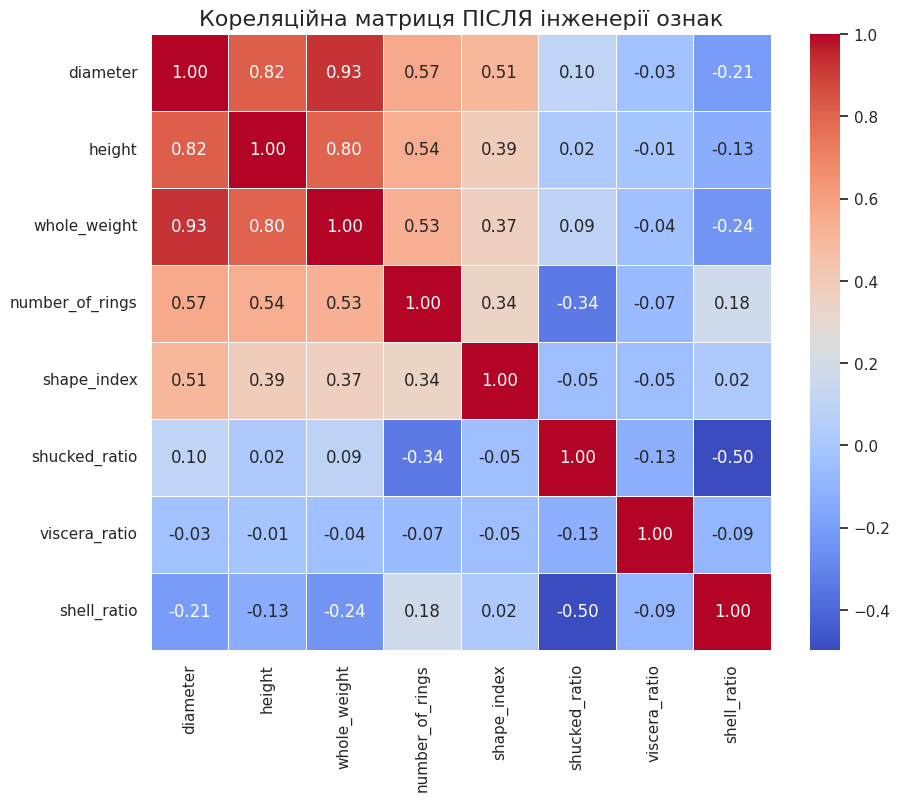

In [45]:
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split

dataset = load_dataset("mstz/abalone")["train"]
df = dataset.to_pandas()


train_df, temp_df = train_test_split(df,test_size = 0.3,random_state=SEED)
val_df, test_df = train_test_split(temp_df,test_size = 0.5,random_state=SEED)
display(train_df.head())
train_df.info()
display(train_df.describe())
print(f"Розмір навчальної вибірки (train): {train_df.shape}")
print(f"Розмір валідаційної вибірки (val): {val_df.shape}")
print(f"Розмір тестової вибірки (test): {test_df.shape}")


print(train_df[train_df.isnull().any(axis = 1)])

sns.set_theme(style="whitegrid")
train_df.hist(figsize=(15, 10), bins=30, edgecolor="black")
plt.suptitle("Розподіл числових ознак (Гістограми)", fontsize=16)
plt.show()
plt.figure(figsize=(10, 8))
corr_matrix = train_df.select_dtypes(include=['number']).corr()


sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Кореляційна матриця", fontsize=16)
plt.show()

numeric_cols = train_df.select_dtypes(include=['number']).columns
print(f"Аномалії по колонках \n{(train_df[numeric_cols] <= 0).sum()}")


train_df = train_df[(train_df[numeric_cols] > 0).all(axis=1)]



def engineer_features(df):
    df_engineered = df.copy()

    # 1. Геометрія: залишаємо diameter для масштабу, shape_index - для форми
    df_engineered['shape_index'] = df_engineered['diameter'] / df_engineered['length']
    df_engineered = df_engineered.drop(columns=['length'])

    # 2. Вага: залишаємо whole_weight для загальної маси, решту робимо пропорціями
    df_engineered['shucked_ratio'] = df_engineered['shucked_weight'] / df_engineered['whole_weight']
    df_engineered['viscera_ratio'] = df_engineered['viscera_weight'] / df_engineered['whole_weight']
    df_engineered['shell_ratio'] = df_engineered['shell_weight'] / df_engineered['whole_weight']

    # Видаляємо старі колонки, які створювали той величезний червоний квадрат мультиколінеарності
    df_engineered = df_engineered.drop(columns=['shucked_weight', 'viscera_weight', 'shell_weight'])
    return df_engineered

train_df = engineer_features(train_df)
val_df = engineer_features(val_df)
test_df = engineer_features(test_df)


print(train_df.head())


# Перевірка результатів інженерії ознак
plt.figure(figsize=(10, 8))
corr_matrix_new = train_df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix_new, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Кореляційна матриця ПІСЛЯ інженерії ознак", fontsize=16)
plt.show()

# До пункту 2.1.2 (Спліт та Data Leakage):

У датасеті Abalone 4177 записів. Пропорція 70/15/15 — це «золота середина» саме для такого об'єму даних.

Навчальна вибірка (Train) — 70% (~2923 записи): Моделям машинного навчання потрібен якомога більший об'єм даних, щоб вловити складні нелінійні закономірності (наприклад, як пропорції тіла впливають на вік). Віддавши 70%, ми забезпечуємо моделі достатню базу для якісного навчання, не залишаючи її "голодною".

Валідаційна вибірка (Val) — 15% (~627 записів): Вона потрібна для підбору гіперпараметрів (налаштування моделі в процесі) та контролю перенавчання (overfitting). Група з понад 600 записів є статистично репрезентативною — тобто метрики помилки на ній будуть стабільними і надійними. Якби ми взяли, наприклад, спліт 80/10/10, то на валідацію пішло б лише 400 рядків, чого може бути замало для об'єктивної оцінки.

Тестова вибірка (Test) — 15% (~627 записів): Це "сліпа" зона, абсолютно ізольовані дані для фінального іспиту моделі. Розмір у ~627 рядків гарантує, що фінальний результат точності (accuracy/error) буде відображати реальну здатність моделі працювати з новими даними, а не є просто випадковим везінням на маленькому тестовому шматочку.

# До пункту 2.1.4 (Обробка пропусків):

Перевірка навчальної вибірки показала відсутність порожніх значень (NaN). Вивід train_df.isnull().any(axis=1) повернув порожній DataFrame. Відповідно, штучно генерувати або заповнювати пропуски не потрібно — дані повні.

# До пункту 2.1.5 (EDA - Аналіз графіків):

З побудованих гістограм та кореляційної матриці впадає в очі наступне:

Скошені розподіли: Ознаки, пов'язані з вагою (whole_weight, shucked_weight тощо), мають виражену правобічну скошеність (right skew) — більшість молюсків мають невелику вагу, але є довгий "хвіст" із рідкісних важких особин.

Мультиколінеарність: Спостерігається надзвичайно висока кореляція між лінійними розмірами (наприклад, між length та diameter вона становить ~0.99). Також сильно корелюють між собою всі типи ваги.

# До пункту 2.1.6 (Обробка викидів):

У навчальній вибірці виявлено 2 записи зі значенням height = 0. З фізичної точки зору молюск не може бути пласким (мати нульову висоту), тому це явна помилка вимірювання або введення даних. Оскільки таких записів мізерна кількість, прийнято рішення їх видалити (з усіх вибірок), щоб вони не вносили шум у математичні розрахунки моделі.

# До пункту 2.1.7 (Інженерія ознак):

У даних було виявлено дві групи ознак із критичною мультиколінеарністю: лінійні розміри та показники ваги. Залишення всіх цих колонок дестабілізувало б моделі через дублювання інформації. Тому інженерія ознак проводилась у два етапи:

Геометричні пропорції: Ознаки length та diameter мали кореляцію 0.99. Щоб не втратити дані про форму молюска, створено ознаку shape_index (відношення діаметра до довжини). Ознаку diameter залишено для збереження масштабу, а length — видалено.

Структура маси: Характеристики shucked_weight, viscera_weight та shell_weight мали надзвичайно високу кореляцію (>0.96) із загальною масою whole_weight. Щоб розв'язати цю проблему, whole_weight залишено як показник абсолютної маси, а інші ознаки перетворено на відсоткові частки від загальної ваги (shucked_ratio, viscera_ratio, shell_ratio). Після цього старі дублюючі колонки ваги було видалено.

# 2.2  Baseline: множинна лінійна регресія

      diameter  height  whole_weight  shape_index  shucked_ratio  \
2830     0.430   0.135        0.8435     0.819048       0.512745   
925      0.325   0.100        0.3645     0.755814       0.432099   
3845     0.350   0.105        0.4160     0.769231       0.390625   
547      0.155   0.045        0.0425     0.756098       0.400000   
2259     0.465   0.160        1.1005     0.788136       0.459791   

      viscera_ratio  shell_ratio  sex_I  sex_M  
2830       0.213397     0.215175    0.0    0.0  
925        0.226337     0.288066    1.0    0.0  
3845       0.233173     0.348558    0.0    1.0  
547        0.129412     0.364706    0.0    1.0  
2259       0.229441     0.268060    0.0    0.0  


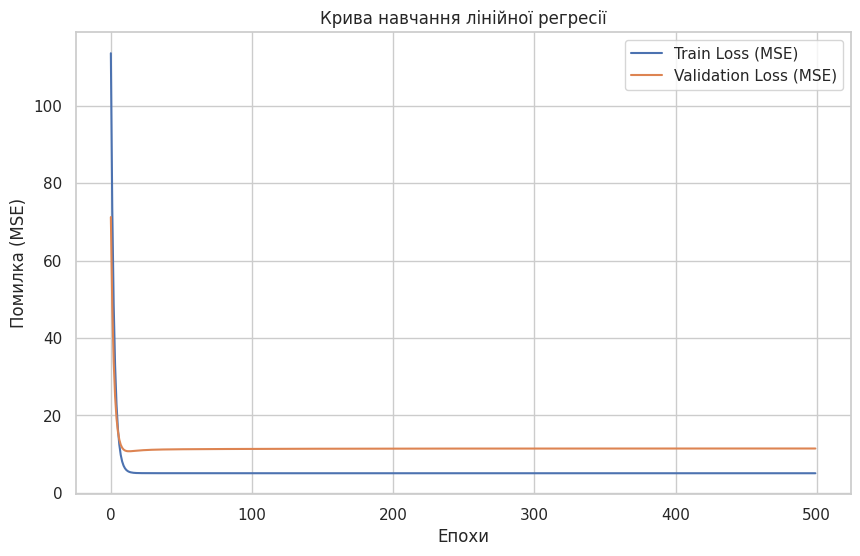

--- МЕТРИКИ НА ТЕСТОВІЙ ВИБІРЦІ ---
MSE  (Середньоквадратична помилка): 14.38
RMSE (Корінь з MSE):                3.79 (в середньому помиляємось на стільки кілець)
MAE  (Абсолютна помилка):           1.73 (в середньому помиляємось на стільки кілець)
R²   (Коефіцієнт детермінації):     -0.40 (наскільки % модель пояснює дані, макс. 1.0)

--- ІНТЕРПРЕТАЦІЯ ВАГ ---
Базовий вік (Bias / Перетин): 9.99
Ваги ознак (відсортовані за впливом):
       Ознака      Вага
     diameter  1.326656
shucked_ratio -1.055545
       height  0.509957
  shell_ratio  0.425776
viscera_ratio -0.279132
        sex_I -0.253824
 whole_weight  0.122598
  shape_index  0.038244
        sex_M  0.010581


In [46]:

import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

if 'sex' in train_df.columns:
    train_df = pd.get_dummies(train_df, columns=['sex'], drop_first=True, dtype=float)
    val_df = pd.get_dummies(val_df, columns=['sex'], drop_first=True, dtype=float)
    test_df = pd.get_dummies(test_df, columns=['sex'], drop_first=True, dtype=float)

# Відділяємо фічі (X) від таргета (y - number_of_rings)
X_train = train_df.drop(columns=['number_of_rings'])
y_train = train_df['number_of_rings']

X_val = val_df.drop(columns=['number_of_rings'])
y_val = val_df['number_of_rings']

X_test = test_df.drop(columns=['number_of_rings'])
y_test = test_df['number_of_rings']

print(X_train.head())

feature_names = X_train.columns

scaler = StandardScaler()
# Навчаємо scaler ТІЛЬКИ на train, а потім просто застосовуємо до val та test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
# view(-1, 1) робить з плоского масиву колонку (вертикальний вектор), це вимога PyTorch
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


input_features = X_train_t.shape[1]
model = nn.Linear(input_features, 1) # 1 вихід - це наш передбачений вік

criterion = nn.MSELoss() # Функція втрат (Середньоквадратична помилка)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1) # Оптимізатор

epochs = 500
train_losses, val_losses = [], []

for epoch in range(epochs):
    # 1. Прямий прохід (Forward pass)
    model.train()
    optimizer.zero_grad() # Обнуляємо градієнти з минулого кроку
    predictions = model(X_train_t)

    # 2. Рахуємо помилку та оновлюємо ваги (Backward pass)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # 3. Валідація (без оновлення ваг)
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t)
        val_losses.append(val_loss.item())

# --- 2.4 КРИВА НАВЧАННЯ ---
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (MSE)')
plt.plot(val_losses, label='Validation Loss (MSE)')
plt.xlabel('Епохи')
plt.ylabel('Помилка (MSE)')
plt.title('Крива навчання лінійної регресії')
plt.legend()
plt.grid(True)
plt.show()


model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_t).numpy()

y_test_true = y_test.values

mse = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)

print(f"--- МЕТРИКИ НА ТЕСТОВІЙ ВИБІРЦІ ---")
print(f"MSE  (Середньоквадратична помилка): {mse:.2f}")
print(f"RMSE (Корінь з MSE):                {rmse:.2f} (в середньому помиляємось на стільки кілець)")
print(f"MAE  (Абсолютна помилка):           {mae:.2f} (в середньому помиляємось на стільки кілець)")
print(f"R²   (Коефіцієнт детермінації):     {r2:.2f} (наскільки % модель пояснює дані, макс. 1.0)\n")

# --- 2.6 ІНТЕРПРЕТАЦІЯ ВАГ ---
weights = model.weight.data.numpy()[0]
bias = model.bias.data.numpy()[0]

print("--- ІНТЕРПРЕТАЦІЯ ВАГ ---")
print(f"Базовий вік (Bias / Перетин): {bias:.2f}")
print("Ваги ознак (відсортовані за впливом):")

# Об'єднуємо назви фіч з їх вагами та сортуємо
feature_weights = pd.DataFrame({'Ознака': feature_names, 'Вага': weights})
feature_weights = feature_weights.sort_values(by='Вага', key=abs, ascending=False)

print(feature_weights.to_string(index=False))

#2.3 Нейромержа 1 архітектура функція активації ReLU

In [47]:
import torch.nn as nn
import torch.optim as optim

model_1 = nn.Sequential(
    nn.Linear(input_features,64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1)
)
criterion = nn.MSELoss()

optimizer_1 = optim.Adam(model_1.parameters(), lr=0.01)

print(model_1)

Sequential(
  (0): Linear(in_features=9, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


# 2.3 Нейромережа 2 архітектура функція активації Leaky ReLU

In [48]:
import torch.nn as nn
import torch.optim as optim

model_2 = nn.Sequential(
    nn.Linear(input_features,64),
    nn.LeakyReLU(),
    nn.Linear(64,32),
    nn.LeakyReLU(),
    nn.Linear(32,1)
)
criterion = nn.MSELoss()

optimizer_2 = optim.Adam(model_2.parameters(), lr=0.01)

print(model_2)

Sequential(
  (0): Linear(in_features=9, out_features=64, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=32, out_features=1, bias=True)
)


# Модель 3: "Широка" мережа з Tanh
У цій архітектурі збільшимо кількість нейронів (128 та 64), але залишимо 2 прихованих шари. Tanh добре працює у широких шарах, бо стискає всі значення в діапазон $(-1, 1)$

In [49]:
model_tanh = nn.Sequential(
    nn.Linear(input_features, 128),
    nn.Tanh(),
    nn.Linear(128, 64),              # 128 -> 64
    nn.Tanh(),
    nn.Linear(64, 1)
)

optimizer_tanh = optim.Adam(model_tanh.parameters(), lr=0.005)

print("--- Модель Tanh (Широка) ---")
print(model_tanh)

--- Модель Tanh (Широка) ---
Sequential(
  (0): Linear(in_features=9, out_features=128, bias=True)
  (1): Tanh()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=1, bias=True)
)


  # Модель 4: "Глибока воронка" з Sigmoid
  Тут зробимо 3 прихованих шари, які поступово зменшуються (48 $\rightarrow$ 24 $\rightarrow$ 12). Sigmoid стискає значення у діапазон $(0, 1)$.

In [50]:
model_sig = nn.Sequential(
    nn.Linear(input_features, 48),   # Вхід у 48
    nn.Sigmoid(),
    nn.Linear(48, 24),               # 48 -> 24
    nn.Sigmoid(),
    nn.Linear(24, 12),               # 24 -> 12
    nn.Sigmoid(),
    nn.Linear(12, 1)                 # Вихід у 1 число
)

optimizer_sig = optim.Adam(model_sig.parameters(), lr=0.01)

print("--- Модель Sigmoid (Глибока воронка) ---")
print(model_sig)

--- Модель Sigmoid (Глибока воронка) ---
Sequential(
  (0): Linear(in_features=9, out_features=48, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=48, out_features=24, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=24, out_features=12, bias=True)
  (5): Sigmoid()
  (6): Linear(in_features=12, out_features=1, bias=True)
)


## Функція тренування

In [51]:
import os
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter


def auto_tensorboard_and_plot(train_func):
    def wrapper(*args, **kwargs):

        model_name = kwargs.get('model_name', 'Model')

        safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "")


        train_losses, val_losses = train_func(*args, **kwargs)


        log_dir = os.path.join("RUNS_DIR", safe_name)
        writer = SummaryWriter(log_dir=log_dir)

        for epoch, (t_loss, v_loss) in enumerate(zip(train_losses, val_losses)):

            writer.add_scalars('Loss', {'Train': t_loss, 'Validation': v_loss}, epoch)
        writer.close()


        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Епохи')
        plt.ylabel('Loss (MSE)')
        plt.title(f'Крива навчання: {model_name}')
        plt.legend()
        plt.grid(True)
        plt.show()

        return train_losses, val_losses
    return wrapper

In [52]:
def train_model(model, optimizer, criterion, X_tr, y_tr, X_v, y_v, epochs=500):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions = model(X_tr)
        loss = criterion(predictions, y_tr)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_preds = model(X_v)
            val_loss = criterion(val_preds, y_v)
            val_losses.append(val_loss.item())

        # Перевірка та вивід кожні 50 епох
        if (epoch + 1) % 50 == 0:
            print(f"Епоха {epoch+1:3d}/{epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    return train_losses, val_losses

@auto_tensorboard_and_plot
def train_model_decorated(model, optimizer, criterion, X_tr, y_tr, X_v, y_v, epochs=500, model_name="Модель"):
    return train_model(model, optimizer, criterion, X_tr, y_tr, X_v, y_v, epochs)



# Функція для оцінки результатів на тесті

In [53]:
def evaluate_model(model, X_test_tensor, y_test_true, model_name="Модель"):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor).numpy()

    mse = mean_squared_error(y_test_true, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_true, preds)
    r2 = r2_score(y_test_true, preds)

    print(f"=== {model_name} ===")
    print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.2f}\n")

    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}



Епоха  50/500 | Train Loss: 5.3585 | Val Loss: 16.1989
Епоха 100/500 | Train Loss: 4.5643 | Val Loss: 7.7830
Епоха 150/500 | Train Loss: 4.3651 | Val Loss: 6.5434
Епоха 200/500 | Train Loss: 4.2364 | Val Loss: 6.0173
Епоха 250/500 | Train Loss: 4.1525 | Val Loss: 5.9343
Епоха 300/500 | Train Loss: 4.0953 | Val Loss: 5.9785
Епоха 350/500 | Train Loss: 4.0531 | Val Loss: 5.9444
Епоха 400/500 | Train Loss: 4.0151 | Val Loss: 5.9153
Епоха 450/500 | Train Loss: 3.9799 | Val Loss: 5.8710
Епоха 500/500 | Train Loss: 3.9365 | Val Loss: 5.8875


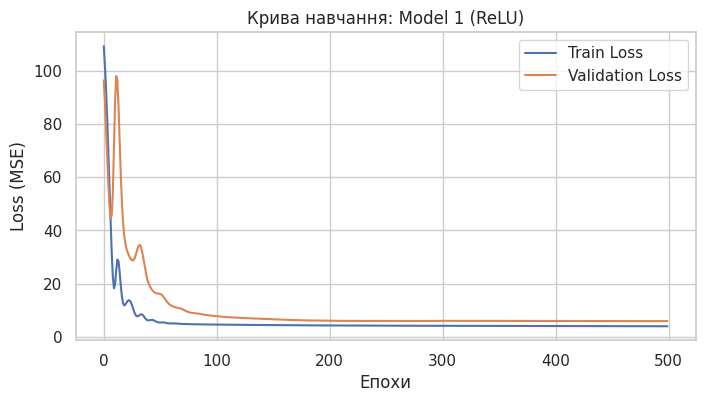

Епоха  50/500 | Train Loss: 5.5676 | Val Loss: 13.8917
Епоха 100/500 | Train Loss: 4.5646 | Val Loss: 7.7881
Епоха 150/500 | Train Loss: 4.3499 | Val Loss: 7.0689
Епоха 200/500 | Train Loss: 4.2425 | Val Loss: 6.8403
Епоха 250/500 | Train Loss: 4.1844 | Val Loss: 6.4766
Епоха 300/500 | Train Loss: 4.1425 | Val Loss: 6.2981
Епоха 350/500 | Train Loss: 4.1090 | Val Loss: 6.0958
Епоха 400/500 | Train Loss: 4.0787 | Val Loss: 6.0544
Епоха 450/500 | Train Loss: 4.0502 | Val Loss: 6.0609
Епоха 500/500 | Train Loss: 4.0239 | Val Loss: 5.9715


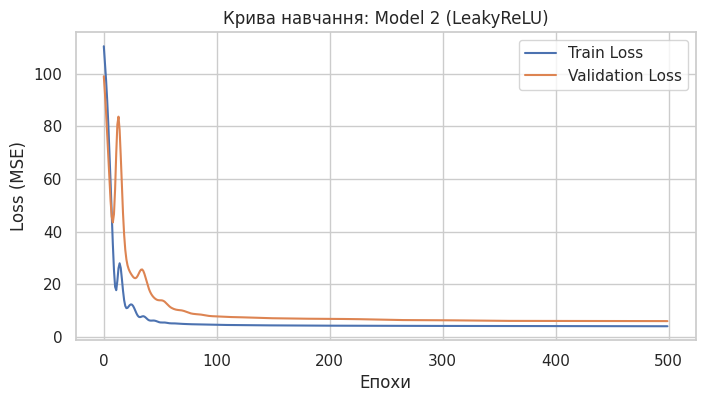

Епоха  50/500 | Train Loss: 6.7016 | Val Loss: 6.3367
Епоха 100/500 | Train Loss: 5.5188 | Val Loss: 5.4371
Епоха 150/500 | Train Loss: 4.5185 | Val Loss: 4.6304
Епоха 200/500 | Train Loss: 4.2139 | Val Loss: 4.4933
Епоха 250/500 | Train Loss: 4.0110 | Val Loss: 4.5074
Епоха 300/500 | Train Loss: 3.8596 | Val Loss: 4.5742
Епоха 350/500 | Train Loss: 3.7261 | Val Loss: 4.6206
Епоха 400/500 | Train Loss: 3.6061 | Val Loss: 4.6477
Епоха 450/500 | Train Loss: 3.4801 | Val Loss: 4.6890
Епоха 500/500 | Train Loss: 3.3536 | Val Loss: 4.7047


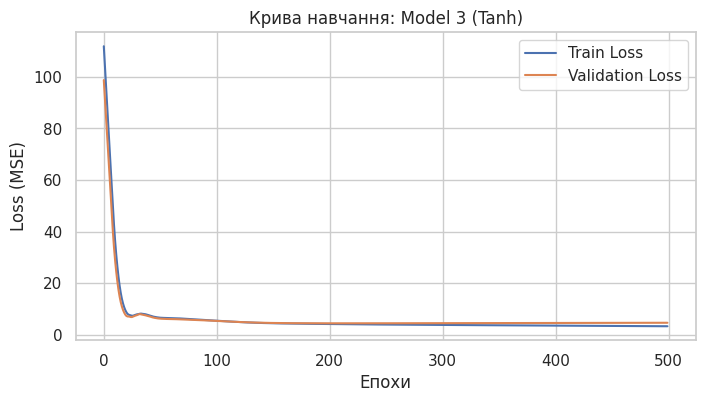

Епоха  50/500 | Train Loss: 25.1890 | Val Loss: 22.3211
Епоха 100/500 | Train Loss: 11.4539 | Val Loss: 10.5294
Епоха 150/500 | Train Loss: 10.4684 | Val Loss: 10.0015
Епоха 200/500 | Train Loss: 9.7720 | Val Loss: 9.2585
Епоха 250/500 | Train Loss: 7.1597 | Val Loss: 6.6584
Епоха 300/500 | Train Loss: 6.2154 | Val Loss: 5.9334
Епоха 350/500 | Train Loss: 5.3746 | Val Loss: 5.2195
Епоха 400/500 | Train Loss: 4.8290 | Val Loss: 4.8801
Епоха 450/500 | Train Loss: 4.4176 | Val Loss: 4.7637
Епоха 500/500 | Train Loss: 4.1191 | Val Loss: 4.7726


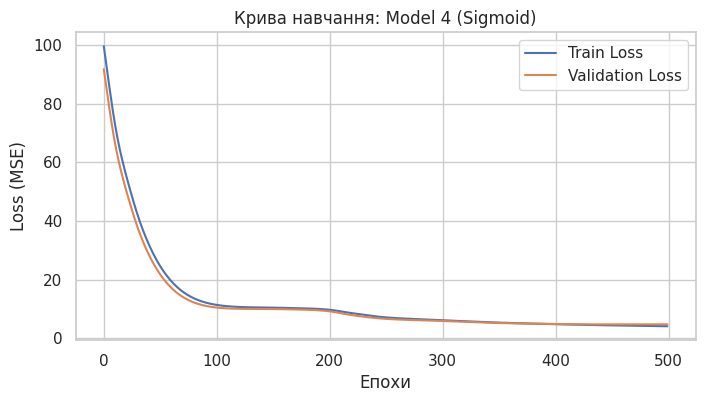

=== Model 1 (ReLU) ===
RMSE: 2.43 | MAE: 1.49 | R²: 0.43

=== Model 2 (LeakyReLU) ===
RMSE: 2.37 | MAE: 1.48 | R²: 0.45

=== Model Tanh ===
RMSE: 2.04 | MAE: 1.45 | R²: 0.60

=== Model Sigmoid ===
RMSE: 2.13 | MAE: 1.50 | R²: 0.56



In [54]:
# Навчаємо Model 1 (ReLU)
t_loss_1, v_loss_1 = train_model_decorated(
    model_1, optimizer_1, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t,
    epochs=500, model_name="Model 1 (ReLU)"
)

# Навчаємо Model 2 (LeakyReLU)
t_loss_2, v_loss_2 = train_model_decorated(
    model_2, optimizer_2, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=500,model_name = "Model 2 (LeakyReLU)"
)

# Навчаємо Model Tanh
t_loss_tanh, v_loss_tanh = train_model_decorated(
    model_tanh, optimizer_tanh, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=500,model_name = "Model 3 (Tanh)"
)

# Навчаємо Model Sigmoid
t_loss_sig, v_loss_sig = train_model_decorated(
    model_sig, optimizer_sig, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=500,model_name = "Model 4 (Sigmoid)"
)

# Виклик для всіх моделей:
res1 = evaluate_model(model_1, X_test_t, y_test_true, "Model 1 (ReLU)")
res2 = evaluate_model(model_2, X_test_t, y_test_true, "Model 2 (LeakyReLU)")
res_tanh = evaluate_model(model_tanh, X_test_t, y_test_true, "Model Tanh")
res_sig = evaluate_model(model_sig, X_test_t, y_test_true, "Model Sigmoid")

# 2.4 Підбір гіпер параметрів
1.L2 Регуляризація (Weight Decay): Штрафує модель за занадто великі ваги (в PyTorch це параметр weight_decay в оптимізаторі).
2.Dropout: Випадково "вимикає" частину нейронів під час навчання, змушуючи мережу не покладатися на конкретні нейрони, а шукати загальні закономірності.

3.Менший Learning Rate (lr): Щоб модель не робила занадто різких кроків.

4.LeakyReLU + оптимізатор AdamW + Dropout

5.Tanh + Батч-нормалізація (BatchNorm1d) + оптимізатор RMSprop

6. Sigmoid + класичний SGD з Momentum (імпульсом) + Dropout

In [55]:
import torch.optim as optim
# =====================================================================
# Варіант 1: Звичайна ReLU, але з L2 регуляризацією (weight_decay)
# =====================================================================
model_relu_l2 = nn.Sequential(
    nn.Linear(input_features, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
# Додаємо weight_decay=1e-3 (штраф за великі ваги)
optimizer_relu_l2 = optim.Adam(model_relu_l2.parameters(), lr=0.01, weight_decay=1e-3)


# =====================================================================
# Варіант 2: Архітектура ReLU + Dropout шари (регуляризація архітектурою)
# =====================================================================
model_relu_dropout = nn.Sequential(
    nn.Linear(input_features, 64),
    nn.ReLU(),
    nn.Dropout(0.2), # Вимикаємо 20% нейронів під час тренування
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 1)
)
optimizer_relu_dropout = optim.Adam(model_relu_dropout.parameters(), lr=0.01)


# =====================================================================
# Варіант 3: Менший Learning Rate + Dropout + більша кількість епох
# =====================================================================
model_relu_slow = nn.Sequential(
    nn.Linear(input_features, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 1)
)
# Зменшили lr до 0.001
optimizer_relu_slow = optim.Adam(model_relu_slow.parameters(), lr=0.001)

# =====================================================================
# Варіант 4: LeakyReLU + оптимізатор AdamW + Dropout
# =====================================================================
model_leaky_adamw = nn.Sequential(
    nn.Linear(input_features, 64),
    nn.LeakyReLU(0.01), # 0.01 - нахил для негативних значень
    nn.Dropout(0.2),
    nn.Linear(64, 32),
    nn.LeakyReLU(0.01),
    nn.Dropout(0.2),
    nn.Linear(32, 1)
)

# Використовуємо AdamW замість Adam для кращої регуляризації
optimizer_leaky_adamw = optim.AdamW(model_leaky_adamw.parameters(), lr=0.01, weight_decay=1e-3)

# =====================================================================
# Варіант 5: Tanh + Батч-нормалізація (BatchNorm1d) + оптимізатор RMSprop
# =====================================================================
model_tanh_bn = nn.Sequential(
    nn.Linear(input_features, 64),
    nn.BatchNorm1d(64), # Нормалізація ПЕРЕД активацією
    nn.Tanh(),
    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.Tanh(),
    nn.Linear(32, 1)
)

# RMSprop - інший популярний адаптивний алгоритм
optimizer_tanh_bn = optim.RMSprop(model_tanh_bn.parameters(), lr=0.005, alpha=0.99)

# ====================================================================
# Варіант 6: Sigmoid + класичний SGD з Momentum (імпульсом) + Dropout
# ====================================================================

model_sig_sgd = nn.Sequential(
    nn.Linear(input_features, 64),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(64, 32),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(32, 1)
)

# Використовуємо класичний SGD, але додаємо momentum
# Для Sigmoid + SGD часто потрібен трохи більший learning rate (наприклад, 0.05 або 0.1)
optimizer_sig_sgd = optim.SGD(model_sig_sgd.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)


# Тренування нових моделей

--- 1. Варіант: ReLU + L2 Reg ---
Епоха  50/500 | Train Loss: 6.1302 | Val Loss: 15.6734
Епоха 100/500 | Train Loss: 4.5475 | Val Loss: 7.0404
Епоха 150/500 | Train Loss: 4.3473 | Val Loss: 6.3667
Епоха 200/500 | Train Loss: 4.1097 | Val Loss: 6.2530
Епоха 250/500 | Train Loss: 3.9459 | Val Loss: 6.2458
Епоха 300/500 | Train Loss: 3.7692 | Val Loss: 6.1910
Епоха 350/500 | Train Loss: 3.5974 | Val Loss: 6.1628
Епоха 400/500 | Train Loss: 3.5159 | Val Loss: 5.9579
Епоха 450/500 | Train Loss: 3.4438 | Val Loss: 6.0753
Епоха 500/500 | Train Loss: 3.3450 | Val Loss: 5.9131


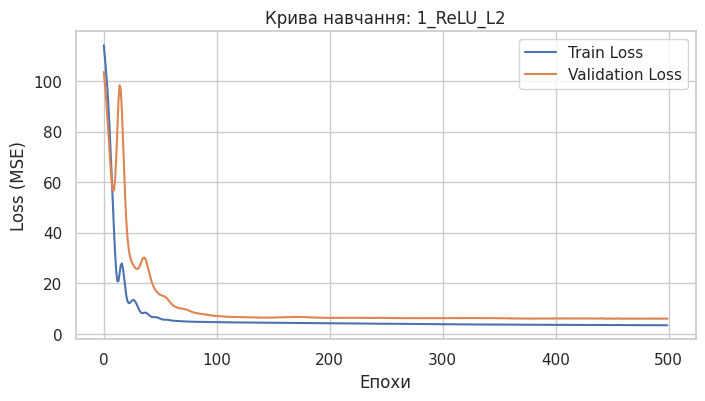

--- 2. Варіант: ReLU + Dropout ---
Епоха  50/500 | Train Loss: 7.9874 | Val Loss: 12.4802
Епоха 100/500 | Train Loss: 6.8603 | Val Loss: 6.4252
Епоха 150/500 | Train Loss: 6.8531 | Val Loss: 5.8973
Епоха 200/500 | Train Loss: 6.4876 | Val Loss: 5.8434
Епоха 250/500 | Train Loss: 6.4885 | Val Loss: 5.3318
Епоха 300/500 | Train Loss: 6.0718 | Val Loss: 5.0222
Епоха 350/500 | Train Loss: 6.0161 | Val Loss: 4.7443
Епоха 400/500 | Train Loss: 6.0798 | Val Loss: 4.6344
Епоха 450/500 | Train Loss: 6.0331 | Val Loss: 4.5383
Епоха 500/500 | Train Loss: 6.0063 | Val Loss: 4.4998


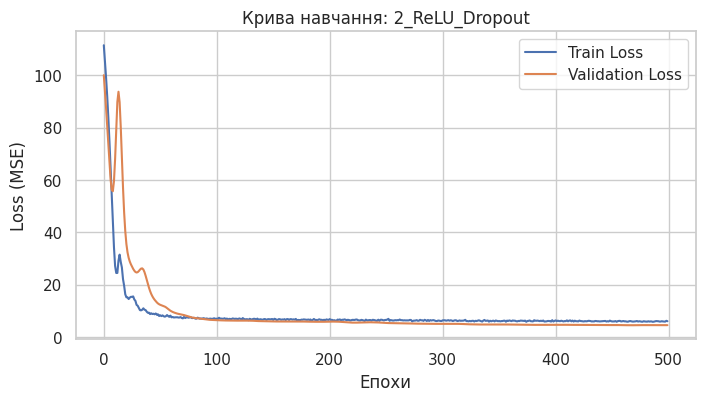

--- 3. Варіант: ReLU + Slow LR + Dropout ---
Епоха  50/1000 | Train Loss: 71.8705 | Val Loss: 67.7984
Епоха 100/1000 | Train Loss: 20.6113 | Val Loss: 41.3318
Епоха 150/1000 | Train Loss: 14.9668 | Val Loss: 36.2295
Епоха 200/1000 | Train Loss: 11.0740 | Val Loss: 29.0649
Епоха 250/1000 | Train Loss: 9.7231 | Val Loss: 21.3562
Епоха 300/1000 | Train Loss: 8.9171 | Val Loss: 15.6705
Епоха 350/1000 | Train Loss: 8.2191 | Val Loss: 12.6211
Епоха 400/1000 | Train Loss: 7.5362 | Val Loss: 11.0398
Епоха 450/1000 | Train Loss: 8.0541 | Val Loss: 9.7240
Епоха 500/1000 | Train Loss: 7.5089 | Val Loss: 8.6126
Епоха 550/1000 | Train Loss: 7.6268 | Val Loss: 8.1600
Епоха 600/1000 | Train Loss: 7.5654 | Val Loss: 7.7039
Епоха 650/1000 | Train Loss: 7.3858 | Val Loss: 7.2574
Епоха 700/1000 | Train Loss: 7.4237 | Val Loss: 6.9611
Епоха 750/1000 | Train Loss: 7.5329 | Val Loss: 6.6869
Епоха 800/1000 | Train Loss: 7.1360 | Val Loss: 6.4344
Епоха 850/1000 | Train Loss: 7.1919 | Val Loss: 6.3267
Епоха 90

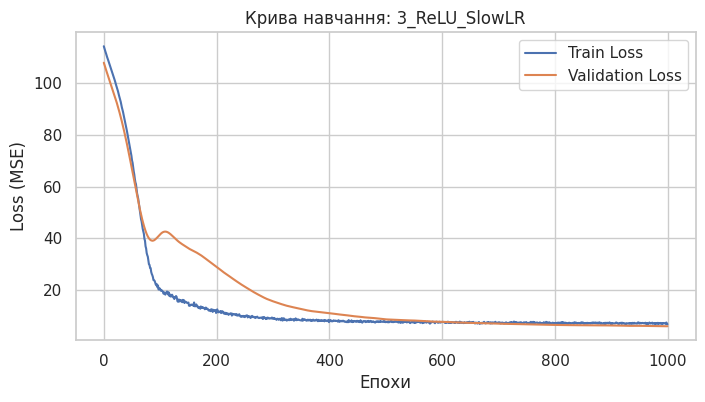

--- 4. Варіант: LeakyReLU + AdamW + Dropout ---
Епоха  50/500 | Train Loss: 8.7774 | Val Loss: 14.4676
Епоха 100/500 | Train Loss: 7.1807 | Val Loss: 7.3861
Епоха 150/500 | Train Loss: 6.8289 | Val Loss: 6.5824
Епоха 200/500 | Train Loss: 6.5487 | Val Loss: 5.9005
Епоха 250/500 | Train Loss: 6.4483 | Val Loss: 5.5556
Епоха 300/500 | Train Loss: 6.0996 | Val Loss: 5.1974
Епоха 350/500 | Train Loss: 5.7652 | Val Loss: 5.0542
Епоха 400/500 | Train Loss: 5.7562 | Val Loss: 5.1488
Епоха 450/500 | Train Loss: 5.4764 | Val Loss: 4.9483
Епоха 500/500 | Train Loss: 5.5506 | Val Loss: 4.9621


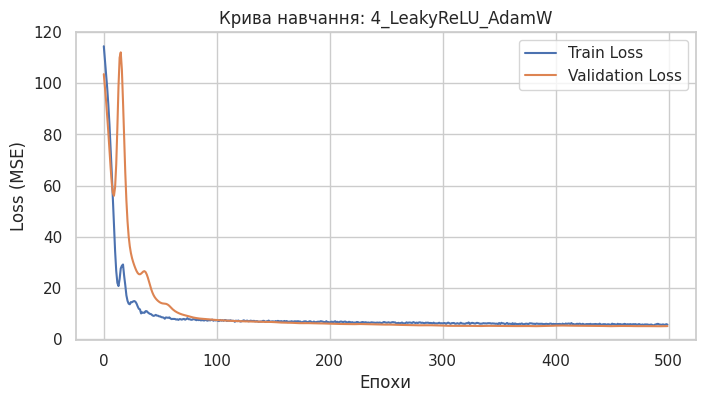

--- 5. Варіант: Tanh + BatchNorm + RMSprop ---
Епоха  50/500 | Train Loss: 4.3041 | Val Loss: 4.5912
Епоха 100/500 | Train Loss: 4.1562 | Val Loss: 4.8366
Епоха 150/500 | Train Loss: 3.9934 | Val Loss: 4.6599
Епоха 200/500 | Train Loss: 3.8122 | Val Loss: 4.8308
Епоха 250/500 | Train Loss: 3.7737 | Val Loss: 4.9606
Епоха 300/500 | Train Loss: 3.7322 | Val Loss: 4.8915
Епоха 350/500 | Train Loss: 3.6641 | Val Loss: 4.9368
Епоха 400/500 | Train Loss: 3.5936 | Val Loss: 4.7852
Епоха 450/500 | Train Loss: 3.6403 | Val Loss: 5.2535
Епоха 500/500 | Train Loss: 3.5278 | Val Loss: 5.1407


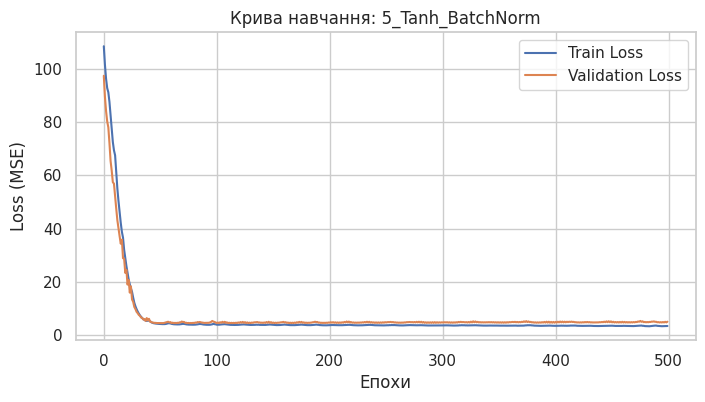

--- 6. Варіант: Sigmoid + SGD Momentum ---
Епоха  50/500 | Train Loss: 8.5682 | Val Loss: 6.8933
Епоха 100/500 | Train Loss: 6.8484 | Val Loss: 5.9625
Епоха 150/500 | Train Loss: 7.0607 | Val Loss: 5.8206
Епоха 200/500 | Train Loss: 7.0262 | Val Loss: 5.8427
Епоха 250/500 | Train Loss: 6.9460 | Val Loss: 5.8315
Епоха 300/500 | Train Loss: 6.7603 | Val Loss: 5.6950
Епоха 350/500 | Train Loss: 6.9236 | Val Loss: 5.7417
Епоха 400/500 | Train Loss: 6.6842 | Val Loss: 5.7437
Епоха 450/500 | Train Loss: 6.9486 | Val Loss: 5.7652
Епоха 500/500 | Train Loss: 7.0685 | Val Loss: 5.7133


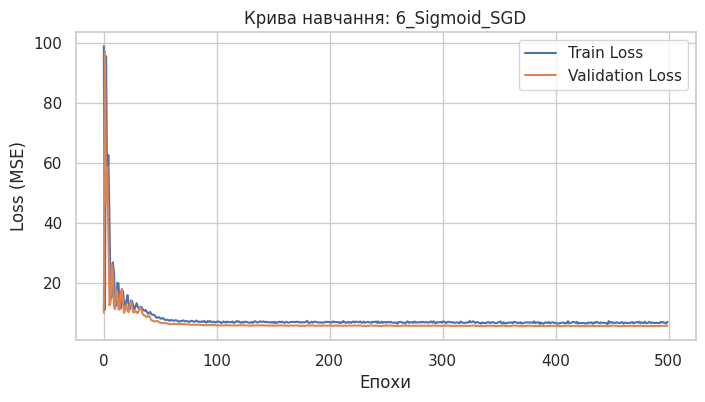

In [56]:
print("--- 1. Варіант: ReLU + L2 Reg ---")
t_loss_1, v_loss_1 = train_model_decorated(
    model_relu_l2, optimizer_relu_l2, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=500, model_name="1_ReLU_L2"
)

print("--- 2. Варіант: ReLU + Dropout ---")
t_loss_2, v_loss_2 = train_model_decorated(
    model_relu_dropout, optimizer_relu_dropout, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=500, model_name="2_ReLU_Dropout"
)

print("--- 3. Варіант: ReLU + Slow LR + Dropout ---")
t_loss_3, v_loss_3 = train_model_decorated(
    model_relu_slow, optimizer_relu_slow, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=1000, model_name="3_ReLU_SlowLR"
)

print("--- 4. Варіант: LeakyReLU + AdamW + Dropout ---")
t_loss_4, v_loss_4 = train_model_decorated(
    model_leaky_adamw, optimizer_leaky_adamw, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=500, model_name="4_LeakyReLU_AdamW"
)

print("--- 5. Варіант: Tanh + BatchNorm + RMSprop ---")
t_loss_5, v_loss_5 = train_model_decorated(
    model_tanh_bn, optimizer_tanh_bn, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=500, model_name="5_Tanh_BatchNorm"
)

print("--- 6. Варіант: Sigmoid + SGD Momentum ---")
t_loss_6, v_loss_6 = train_model_decorated(
    model_sig_sgd, optimizer_sig_sgd, criterion,
    X_train_t, y_train_t, X_val_t, y_val_t, epochs=500, model_name="6_Sigmoid_SGD"
)

# Функція для фінальної таблиці (Пункт 2.5)

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_and_log_model(model, X_test_tensor, y_test_true, model_name="Модель"):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor).numpy()

    mse = mean_squared_error(y_test_true, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_true, preds)
    r2 = r2_score(y_test_true, preds)

    # Виводимо в консоль
    print(f"[{model_name}] RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

    # Повертаємо словник для таблиці
    return {
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [58]:

all_results = []

all_results.append(evaluate_and_log_model(model, X_test_t, y_test_true, "0. Baseline Linear"))


all_results.append(evaluate_and_log_model(model_1, X_test_t, y_test_true, "Base: ReLU"))
all_results.append(evaluate_and_log_model(model_2, X_test_t, y_test_true, "Base: LeakyReLU"))
all_results.append(evaluate_and_log_model(model_tanh, X_test_t, y_test_true, "Base: Tanh"))
all_results.append(evaluate_and_log_model(model_sig, X_test_t, y_test_true, "Base: Sigmoid"))


all_results.append(evaluate_and_log_model(model_relu_l2, X_test_t, y_test_true, "Tuned: ReLU + L2"))
all_results.append(evaluate_and_log_model(model_relu_dropout, X_test_t, y_test_true, "Tuned: ReLU + Dropout"))
all_results.append(evaluate_and_log_model(model_relu_slow, X_test_t, y_test_true, "Tuned: ReLU + Slow LR"))
all_results.append(evaluate_and_log_model(model_leaky_adamw, X_test_t, y_test_true, "Tuned: LeakyReLU + AdamW"))
all_results.append(evaluate_and_log_model(model_tanh_bn, X_test_t, y_test_true, "Tuned: Tanh + BatchNorm"))
all_results.append(evaluate_and_log_model(model_sig_sgd, X_test_t, y_test_true, "Tuned: Sigmoid + SGD"))


results_df = pd.DataFrame(all_results)


results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

print("\n=== ФІНАЛЬНИЙ РЕЙТИНГ УСІХ МОДЕЛЕЙ ===")
display(results_df)

[0. Baseline Linear] RMSE: 3.7918 | MAE: 1.7256 | R²: -0.4007
[Base: ReLU] RMSE: 2.4288 | MAE: 1.4876 | R²: 0.4253
[Base: LeakyReLU] RMSE: 2.3659 | MAE: 1.4838 | R²: 0.4547
[Base: Tanh] RMSE: 2.0367 | MAE: 1.4468 | R²: 0.5959
[Base: Sigmoid] RMSE: 2.1315 | MAE: 1.4988 | R²: 0.5574
[Tuned: ReLU + L2] RMSE: 2.4102 | MAE: 1.5335 | R²: 0.4341
[Tuned: ReLU + Dropout] RMSE: 2.0551 | MAE: 1.4211 | R²: 0.5885
[Tuned: ReLU + Slow LR] RMSE: 2.2897 | MAE: 1.4766 | R²: 0.4892
[Tuned: LeakyReLU + AdamW] RMSE: 2.1584 | MAE: 1.4261 | R²: 0.5461
[Tuned: Tanh + BatchNorm] RMSE: 2.1089 | MAE: 1.5445 | R²: 0.5667
[Tuned: Sigmoid + SGD] RMSE: 2.3044 | MAE: 1.6906 | R²: 0.4826

=== ФІНАЛЬНИЙ РЕЙТИНГ УСІХ МОДЕЛЕЙ ===


,Model,MSE,RMSE,MAE,R2
0,Base: Tanh,4.148172,2.036706,1.446843,0.595872
1,Tuned: ReLU + Dropout,4.223519,2.055120,1.421131,0.588531
2,Tuned: Tanh + BatchNorm,4.447265,2.108854,1.544504,0.566733
3,Base: Sigmoid,4.543180,2.131474,1.498836,0.557389
4,Tuned: LeakyReLU + AdamW,4.658624,2.158385,1.426060,0.546142
5,Tuned: ReLU + Slow LR,5.242888,2.289735,1.476551,0.489221
6,Tuned: Sigmoid + SGD,5.310346,2.304419,1.690614,0.482649
7,Base: LeakyReLU,5.597558,2.365916,1.483819,0.454668
8,Tuned: ReLU + L2,5.809055,2.410198,1.533460,0.434063
9,Base: ReLU,5.899017,2.428789,1.487579,0.425299


# Відповіді на питання

- Яка модель перемогла і наскільки суттєво?

Переможцем стала базова архітектура з функцією активації Tanh, показавши найнижче значення RMSE (2.036706) та найвищий R² (0.595872). Її відрив від другого місця (Tuned: ReLU + Dropout з RMSE 2.055120) є мінімальним, проте порівняно з найгіршою нейромережею (Base: ReLU з RMSE 2.428789) перемога є суттєвою.
- Чи виправдала себе нейромережа порівняно з лінійною регресією на вашому датасеті?

Нейромережі абсолютно виправдали себе. Базова лінійна регресія показала найгірший результат із від'ємним R² (-0.400713) та найбільшою помилкою RMSE (3.791783). Натомість найкраща нейромережа зменшила помилку майже вдвічі, що доводить складну нелінійну природу залежностей у цих даних.
- Що з ваших змін (архітектура чи гіперпараметри) дало найбільший ефект?

Найбільший загальний ефект дав базовий вибір архітектури (функції активації), оскільки модель Tanh без жодного додаткового тюнінгу очолила рейтинг. Проте серед налаштувань гіперпараметрів найефективнішим виявився Dropout: його додавання до базової архітектури ReLU підняло модель з 10-го місця (RMSE 2.428789) на 2-ге (RMSE 2.055120)

In [59]:
import os
import shutil
import torch
from google.colab import drive

drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/SAI/lab2"
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"Робоча папка: {DRIVE_PATH}")

results_df.to_csv(f"{DRIVE_PATH}/results.csv", index=False)
print("Таблиця results.csv збережена!")

# Лінійна регресія
torch.save(model.state_dict(), f"{DRIVE_PATH}/models/linear.pt")

# Варіанти нейромереж (nn_v1.pt ... nn_v10.pt)
torch.save(model_1.state_dict(), f"{DRIVE_PATH}/models/nn_v1.pt")
torch.save(model_2.state_dict(), f"{DRIVE_PATH}/models/nn_v2.pt")
torch.save(model_tanh.state_dict(), f"{DRIVE_PATH}/models/nn_v3.pt")
torch.save(model_sig.state_dict(), f"{DRIVE_PATH}/models/nn_v4.pt")

torch.save(model_relu_l2.state_dict(), f"{DRIVE_PATH}/models/nn_v5.pt")
torch.save(model_relu_dropout.state_dict(), f"{DRIVE_PATH}/models/nn_v6.pt")
torch.save(model_relu_slow.state_dict(), f"{DRIVE_PATH}/models/nn_v7.pt")
torch.save(model_leaky_adamw.state_dict(), f"{DRIVE_PATH}/models/nn_v8.pt")
torch.save(model_tanh_bn.state_dict(), f"{DRIVE_PATH}/models/nn_v9.pt")
torch.save(model_sig_sgd.state_dict(), f"{DRIVE_PATH}/models/nn_v10.pt")
print("Всі 11 моделей перезаписані!")

target_runs_path = f"{DRIVE_PATH}/runs"

if os.path.exists("RUNS_DIR"):
    if os.path.exists(target_runs_path):
        print("Видалення старих логів з Диска...")
        shutil.rmtree(target_runs_path)

    print("Копіювання нових логів...")
    shutil.copytree("RUNS_DIR", target_runs_path)
    print("Папка runs/ успішно оновлена!")
else:
    print("Папку RUNS_DIR не знайдено в Colab. Переконайся, що моделі тренувалися.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Робоча папка: /content/drive/MyDrive/SAI/lab2
Таблиця results.csv збережена!
Всі 11 моделей перезаписані!
Видалення старих логів з Диска...
Копіювання нових логів...
Папка runs/ успішно оновлена!


In [60]:
# Беремо 1 випадковий рядок з оригінального датасету
sample = df.sample(1).iloc[0]

print("--- Підстав ці дані в повзунки Gradio ---")
print(f"Diameter: {sample['diameter']:.3f}")
print(f"Height: {sample['height']:.3f}")
print(f"Whole Weight: {sample['whole_weight']:.3f}")
print(f"Shucked Weight: {sample['shucked_weight']:.3f}")
print(f"Viscera Weight: {sample['viscera_weight']:.3f}")
print(f"Shell Weight: {sample['shell_weight']:.3f}")
print(f"Sex: {sample['sex']}")
print("-" * 40)
print(f"🎯 СПРАВЖНІЙ ВІК ЦЬОГО МОЛЮСКА: {sample['number_of_rings']} кілець")

--- Підстав ці дані в повзунки Gradio ---
Diameter: 0.455
Height: 0.160
Whole Weight: 1.103
Shucked Weight: 0.421
Viscera Weight: 0.301
Shell Weight: 0.325
Sex: M
----------------------------------------
🎯 СПРАВЖНІЙ ВІК ЦЬОГО МОЛЮСКА: 9 кілець


---
## 3. Gradio-застосунок: порівняння всіх варіантів наживо

Побудуйте аппку для своїх моделей

In [61]:
import gradio as gr


# 1. Переводимо ВСІ моделі в режим оцінки
model.eval()               # Baseline Linear
model_1.eval()             # Base: ReLU
model_2.eval()             # Base: LeakyReLU
model_tanh.eval()          # Base: Tanh
model_sig.eval()           # Base: Sigmoid
model_relu_l2.eval()       # Tuned: ReLU + L2
model_relu_dropout.eval()  # Tuned: ReLU + Dropout
model_relu_slow.eval()     # Tuned: ReLU + Slow LR
model_leaky_adamw.eval()   # Tuned: LeakyReLU + AdamW
model_tanh_bn.eval()       # Tuned: Tanh + BatchNorm
model_sig_sgd.eval()       # Tuned: Sigmoid + SGD

def predict_rings_live(diameter, height, whole_weight, shucked_weight, viscera_weight, shell_weight, sex):
    # Відтворюємо інженерію ознак
    shape_index = diameter / height if height > 0 else 0
    shucked_ratio = shucked_weight / whole_weight if whole_weight > 0 else 0
    viscera_ratio = viscera_weight / whole_weight if whole_weight > 0 else 0
    shell_ratio = shell_weight / whole_weight if whole_weight > 0 else 0

    # Обробка статі
    sex_I = 1.0 if sex == 'I' else 0.0
    sex_M = 1.0 if sex == 'M' else 0.0

    # Формуємо DataFrame з тими ж колонками, що були під час тренування
    input_dict = {
        'diameter': [diameter],
        'height': [height],
        'whole_weight': [whole_weight],
        'shape_index': [shape_index],
        'shucked_ratio': [shucked_ratio],
        'viscera_ratio': [viscera_ratio],
        'shell_ratio': [shell_ratio],
        'sex_I': [sex_I],
        'sex_M': [sex_M]
    }
    input_data = pd.DataFrame(input_dict)[feature_names]

    # Масштабування
    input_scaled = scaler.transform(input_data)
    input_tensor = torch.tensor(input_scaled, dtype=torch.float32)

    # Збираємо прогнози від усіх 11 моделей
    with torch.no_grad():
        p_linear = model(input_tensor).item()
        p_base_relu = model_1(input_tensor).item()
        p_base_leaky = model_2(input_tensor).item()
        p_base_tanh = model_tanh(input_tensor).item()
        p_base_sig = model_sig(input_tensor).item()

        p_tuned_relu_l2 = model_relu_l2(input_tensor).item()
        p_tuned_relu_drop = model_relu_dropout(input_tensor).item()
        p_tuned_relu_slow = model_relu_slow(input_tensor).item()
        p_tuned_leaky_adamw = model_leaky_adamw(input_tensor).item()
        p_tuned_tanh_bn = model_tanh_bn(input_tensor).item()
        p_tuned_sig_sgd = model_sig_sgd(input_tensor).item()

    return (
        f"{p_base_tanh:.1f} кілець",
        f"{p_tuned_relu_drop:.1f} кілець",
        f"{p_tuned_tanh_bn:.1f} кілець",
        f"{p_base_sig:.1f} кілець",
        f"{p_tuned_leaky_adamw:.1f} кілець",
        f"{p_tuned_relu_slow:.1f} кілець",
        f"{p_tuned_sig_sgd:.1f} кілець",
        f"{p_base_leaky:.1f} кілець",
        f"{p_tuned_relu_l2:.1f} кілець",
        f"{p_base_relu:.1f} кілець",
        f"{p_linear:.1f} кілець"
    )

# Створюємо інтерфейс Gradio
iface = gr.Interface(
    fn=predict_rings_live,
    inputs=[
        gr.Slider(0.05, 0.8, value=0.4, label="Diameter (Діаметр)"),
        gr.Slider(0.01, 0.3, value=0.1, label="Height (Висота)"),
        gr.Slider(0.05, 3.0, value=1.0, label="Whole Weight (Загальна вага)"),
        gr.Slider(0.01, 1.5, value=0.4, label="Shucked Weight (Вага м'яса)"),
        gr.Slider(0.01, 0.8, value=0.2, label="Viscera Weight (Вага нутрощів)"),
        gr.Slider(0.01, 1.0, value=0.3, label="Shell Weight (Вага мушлі)"),
        gr.Radio(["M", "F", "I"], value="M", label="Sex (Стать)")
    ],
    outputs=[
        gr.Textbox(label="🏆 1. Base: Tanh"),
        gr.Textbox(label="🥈 2. Tuned: ReLU + Dropout"),
        gr.Textbox(label="🥉 3. Tuned: Tanh + BatchNorm"),
        gr.Textbox(label="4. Base: Sigmoid"),
        gr.Textbox(label="5. Tuned: LeakyReLU + AdamW"),
        gr.Textbox(label="6. Tuned: ReLU + Slow LR"),
        gr.Textbox(label="7. Tuned: Sigmoid + SGD"),
        gr.Textbox(label="8. Base: LeakyReLU"),
        gr.Textbox(label="9. Tuned: ReLU + L2"),
        gr.Textbox(label="10. Base: ReLU"),
        gr.Textbox(label="🤡 11. Baseline Linear")
    ],
    title="Abalone Age Predictor: Порівняння всіх 11 моделей",
    description="Змінюй параметри молюска повзунками і спостерігай, як різні архітектури та методи регуляризації впливають на фінальний прогноз."
)

iface.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1f8c289f40a5a14f7b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1f8c289f40a5a14f7b.gradio.live


---
### Як здавати лабу

У форму (https://forms.gle/8Dbc9zB8L5tsNuNEA) здати посилання на **публічний** репозиторій, який містить:

1. **Цей ноутбук з усіма виконаними пунктами**. Має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Файли всіх натренованих варіантів моделі** (2.2-2.4) — лінійна регресія + всі варіанти нейромережі, кожен окремим `.pt` файлом.
3. **Логи TensorBoard** — папка `runs/` з усіма прогонами, щоб можна було відкрити криві навчання, не перезапускаючи ноутбук.
4. **Таблицю результатів** — `results.csv` з порівнянням усіх варіантів (модель, MSE, RMSE, MAE, R² на test).
5. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
/lab2/nn_task.ipynb
/lab2/models/linear.pt
/lab2/models/nn_v1.pt
/lab2/models/nn_v2.pt
/lab2/models/...        (усі інші варіанти з 2.3-2.4)
/lab2/runs/*
/lab2/results.csv
```